In [66]:
import matplotlib.pyplot as plt
from neuralop.data.datasets.navier_stokes import NavierStokesDataset, load_navier_stokes_pt
from neuralop.layers.embeddings import GridEmbedding2D
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.utils import count_model_params
from neuralop import LpLoss, H1Loss
import numpy as np
import torch
# from neuralop.models import OTNO
import neuralop

device = "cuda" #GPU

In [67]:
print(neuralop.__version__)

2.0.0


In [12]:
# 데이터 다운로드
NavierStokesDataset(
    root_dir= "/home/seongwon/AI/neural operator/data(2D_N-S)",
    n_train=1000, n_tests=[200], batch_size=1, test_batch_sizes=[32], train_resolution=128,
    test_resolutions=[128],
)


Loading test db for resolution 128 with 200 samples 


In [16]:
train_loader, test_loaders, data_processor = load_navier_stokes_pt(
    data_root= "/home/seongwon/AI/neural operator/data(2D_N-S)",
    n_train=1000, n_tests=[200], batch_size=64, test_batch_sizes=[32]
    )

Loading test db for resolution 128 with 200 samples 


In [26]:
next(iter(train_loader))['x'].shape

torch.Size([64, 1, 128, 128])

In [34]:
model = FNO(
    n_modes = (8, 8),
    in_channels = 1,
    out_channels = 1,
    hidden_channels = 24,
    projection_channel_ratio= 2,
)

model = model.to(device) 

# Count and display the number of parameters in the model
n_params = count_model_params(model)
print(f"Number of parameters in the model: {n_params}")


Number of parameters in the model: 191881


In [37]:
# creating the optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) # CosineAnnealingLR는 학습률을 코사인 함수 형태로 조정하는 스케줄러입니다. T_max는 한 사이클의 길이를 나타냄 여기서는 30 에폭마다 학습률이 초기값으로 돌아오도록 설정되어 있음

In [38]:
# Setting up loss functions

l2loss = LpLoss(d=2, p=2) # L2 loss for function values
h1loss = H1Loss(d=2)  # H1 loss includes gradient information

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}

In [39]:
# Creating the trainer
trainer = Trainer(
    model=model,
    n_epochs=15,
    device=device,
    data_processor=data_processor,
    wandb_log=False,  # Disable Weights & Biases logging for this tutorial
    eval_interval=5,  # Evaluate every 5 epochs
    use_distributed=False,  # Single GPU/CPU training
    verbose=True,  # Print training progress
)


trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    eval_losses=eval_losses,
)

Training on 1000 samples
Testing on [200] samples         on resolutions [128].


/home/seongwon/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1787: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([64, 1, 128, 128])


/home/seongwon/anaconda3/lib/python3.13/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=3.34, avg_loss=0.9070, train_err=56.6902


/home/seongwon/anaconda3/lib/python3.13/site-packages/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)


Eval: 128_h1=0.8193, 128_l2=0.6173
[5] time=2.62, avg_loss=0.4855, train_err=30.3453
Eval: 128_h1=0.4682, 128_l2=0.2134
[10] time=2.62, avg_loss=0.3988, train_err=24.9254
Eval: 128_h1=0.4003, 128_l2=0.1726


{'train_err': 23.16839951276779,
 'avg_loss': 0.3706943922042847,
 'avg_lasso_loss': None,
 'epoch_train_time': 2.6365723979542963}

/tmp/ipykernel_685556/2453812260.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


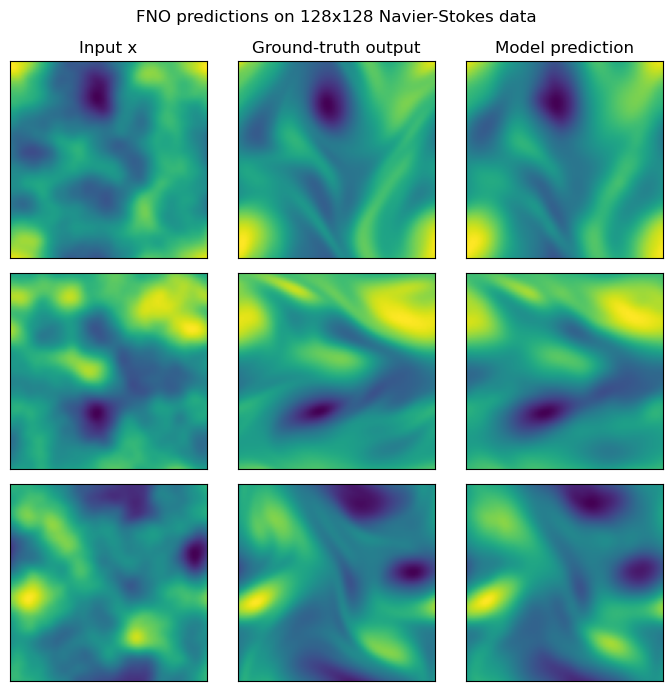

In [48]:
test_samples = test_loaders[128].dataset

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    data = test_samples[index]
    data = data_processor.preprocess(data, batched=False)

    # Input
    x = data["x"]
    # Ground-truth output
    y = data["y"]
    # Model prediction
    out = model(x.unsqueeze(0))

    # Plot input
    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x.cpu()[0])
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot ground-truth output
    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.cpu().squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot model prediction
    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.cpu().squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on 128x128 Navier-Stokes data", y=0.98)
plt.tight_layout()
fig.show()

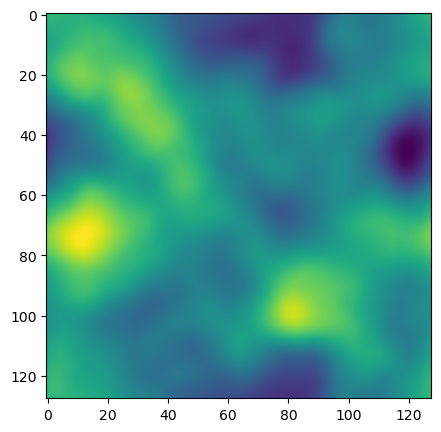

In [59]:
plt.figure(figsize=(5, 5))
plt.imshow(x.cpu()[0], interpolation="lanczos")